# KKBox — Final Model & Churn Risk Ranking

Trains the final LightGBM model on pipeline v2 features, evaluates it on the validation set, builds the full user ranking by churn probability, and saves everything to `reports/`.

Model selection and iteration notes are in `07_pipeline_v2_boosting_ranking.ipynb` and `docs/iterations/v2_final.md`. This notebook is just the clean final run.

The output is a ranked list of users sorted by `churn_proba`. For a retention team with a limited outreach budget, the right move is to contact users from the top of that list down — the Recall@K table in Section 5 shows how many churners you'd capture at different budget sizes.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

import lightgbm as lgb

from src.pipeline_v2 import FEATURES_V3 as FEATURE_COLS

RANDOM_STATE = 42
DATA_PATH = ROOT / "data" / "processed" / "df_model_v2.csv"
REPORTS_DIR = ROOT / "reports"

print(f"Root:         {ROOT}")
print(f"Data exists:  {DATA_PATH.is_file()}")
print(f"Features:     {len(FEATURE_COLS)}")

Root:         C:\Users\simon\Desktop\kkbox-ml
Data exists:  True
Features:     44


## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)

missing = set(FEATURE_COLS) - set(df.columns)
assert not missing, f"Missing columns: {missing}"

X = df[FEATURE_COLS].copy()
y = df["is_churn"].astype(int)

user_ids = df["msno"] if "msno" in df.columns else pd.Series(range(len(df)), name="msno")

print(f"Dataset shape:   {df.shape}")
print(f"Churn rate:      {y.mean():.2%} ({y.sum():,} users)")
print(f"Feature columns: {len(FEATURE_COLS)}")

Dataset shape:   (970960, 46)
Churn rate:      8.99% (87,330 users)
Feature columns: 44


## 2. Train / validation split

Identical 80/20 stratified split and random seed used throughout the project, so validation metrics are directly comparable across all notebooks.

In [3]:
idx = np.arange(len(X))
idx_train, idx_val = train_test_split(
    idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val = X.iloc[idx_train], X.iloc[idx_val]
y_train, y_val = y.iloc[idx_train], y.iloc[idx_val]
ids_val = user_ids.iloc[idx_val].reset_index(drop=True)

n_val = len(y_val)
n_churn_val = int(y_val.sum())
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print(f"Validation churn: {y_val.mean():.2%} ({n_churn_val:,} users)")

Train: (776768, 44)  |  Val: (194192, 44)
Validation churn: 8.99% (17,466 users)


## 3. Train final model — LightGBM

Same config used during model selection in notebook 07. `class_weight='balanced'` handles the 9% churn rate without resampling. Early stopping on validation log-loss, patience=50.

In [4]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

print(f"Best iteration: {model.best_iteration_}")

[100]	valid_0's binary_logloss: 0.518804
[200]	valid_0's binary_logloss: 0.513282
[300]	valid_0's binary_logloss: 0.510776
[400]	valid_0's binary_logloss: 0.508685
[500]	valid_0's binary_logloss: 0.506511
[600]	valid_0's binary_logloss: 0.504546
[700]	valid_0's binary_logloss: 0.502733
[800]	valid_0's binary_logloss: 0.50086
[900]	valid_0's binary_logloss: 0.499033
[1000]	valid_0's binary_logloss: 0.497327
Best iteration: 1000


## 4. Evaluation

### 4.1 Scalar metrics

In [5]:
val_proba = model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

metrics = {
    "roc_auc":          round(float(roc_auc_score(y_val, val_proba)), 4),
    "avg_precision":    round(float(average_precision_score(y_val, val_proba)), 4),
    "precision_at_0.5": round(float(precision_score(y_val, val_pred, zero_division=0)), 4),
    "recall_at_0.5":    round(float(recall_score(y_val, val_pred, zero_division=0)), 4),
    "f1_at_0.5":        round(float(f1_score(y_val, val_pred, zero_division=0)), 4),
    "val_churn_rate":   round(float(y_val.mean()), 4),
    "n_val":            int(n_val),
    "n_val_churners":   int(n_churn_val),
    "model":            "LightGBM",
    "pipeline":         "v2",
    "n_features":       len(FEATURE_COLS),
}

for k, v in metrics.items():
    print(f"  {k:<22} {v}")

  roc_auc                0.7778
  avg_precision          0.4758
  precision_at_0.5       0.2855
  recall_at_0.5          0.5751
  f1_at_0.5              0.3815
  val_churn_rate         0.0899
  n_val                  194192
  n_val_churners         17466
  model                  LightGBM
  pipeline               v2
  n_features             44


### 4.2 Classification report

In [6]:
print(classification_report(y_val, val_pred, target_names=["no churn", "churn"]))

              precision    recall  f1-score   support

    no churn       0.95      0.86      0.90    176726
       churn       0.29      0.58      0.38     17466

    accuracy                           0.83    194192
   macro avg       0.62      0.72      0.64    194192
weighted avg       0.89      0.83      0.86    194192



### 4.3 ROC and PR curves

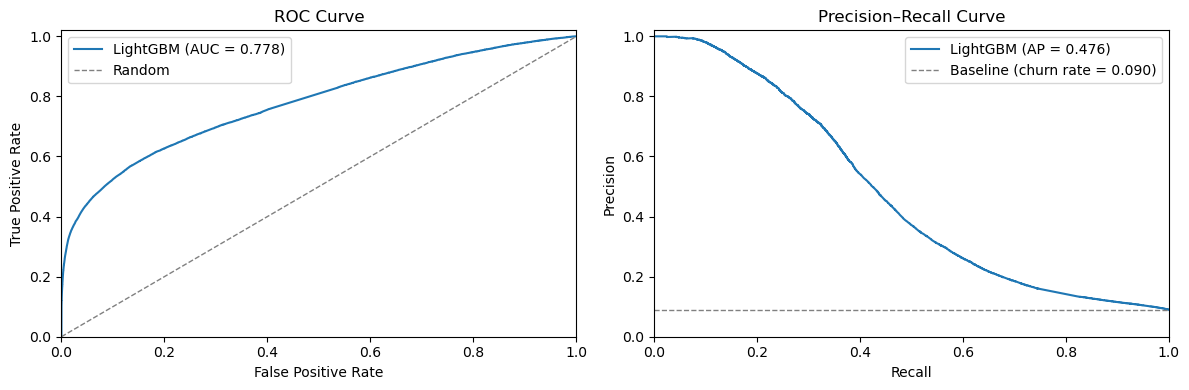

Saved: reports/metrics/roc_pr_curves.png


In [7]:
fpr, tpr, _ = roc_curve(y_val, val_proba)
prec_curve, rec_curve, _ = precision_recall_curve(y_val, val_proba)
churn_rate = y_val.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC
ax = axes[0]
ax.plot(fpr, tpr, label=f"LightGBM (AUC = {metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# PR
ax = axes[1]
ax.plot(rec_curve, prec_curve, label=f"LightGBM (AP = {metrics['avg_precision']:.3f})")
ax.axhline(churn_rate, color="gray", linestyle="--", linewidth=1,
           label=f"Baseline (churn rate = {churn_rate:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve")
ax.legend(loc="upper right")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
fig.savefig(REPORTS_DIR / "metrics" / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/metrics/roc_pr_curves.png")

## 5. Ranking — Recall@K

Sort users by predicted probability (highest first). Recall@K is the fraction of all churners that appear in the top K. It's the natural way to evaluate the model when you have a fixed outreach budget.

In [8]:
def recall_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> float:
    order = np.argsort(-y_score)
    n_pos = int(y_true.sum())
    if n_pos == 0:
        return 0.0
    hits = int(y_true[order[:k]].sum())
    return hits / n_pos


def precision_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> float:
    order = np.argsort(-y_score)
    hits = int(y_true[order[:k]].sum())
    return hits / k


y_true_np = y_val.to_numpy()

k_values = [5_000, 10_000, 25_000, 50_000, 100_000]
rows = []
for k in k_values:
    k = min(k, n_val)
    rec = recall_at_k(y_true_np, val_proba, k)
    prec = precision_at_k(y_true_np, val_proba, k)
    rows.append({
        "K": k,
        "% of users": f"{100 * k / n_val:.1f}%",
        "recall_at_K": round(rec, 4),
        "precision_at_K": round(prec, 4),
        "churners_reached": int(rec * n_churn_val),
    })

rank_df = pd.DataFrame(rows)
display(rank_df)

metrics["recall_at_K"] = {row["K"]: row["recall_at_K"] for row in rows}

,K,% of users,recall_at_K,precision_at_K,churners_reached
0,5000,2.6%,0.2382,0.8320,4160
1,10000,5.1%,0.3606,0.6299,6299
2,25000,12.9%,0.5112,0.3572,8928
3,50000,25.7%,0.6411,0.2239,11197
4,100000,51.5%,0.8015,0.1400,13999


### 5.1 Recall@K vs random baseline

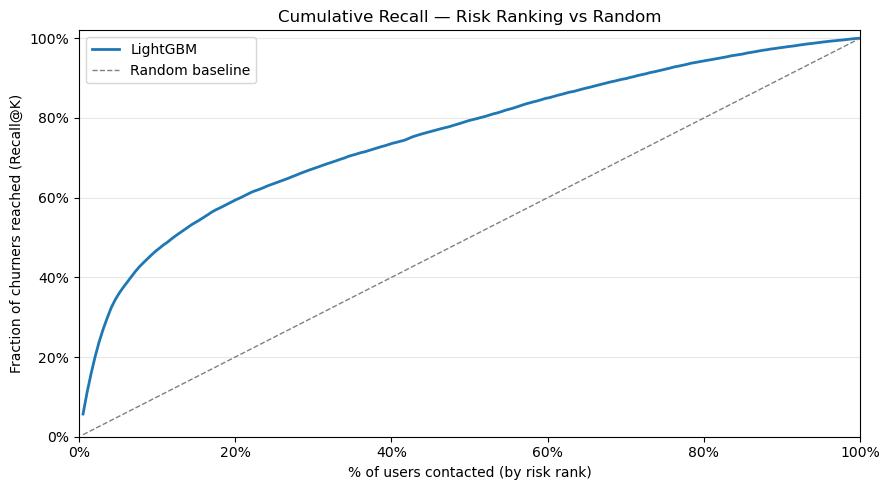

Saved: reports/metrics/recall_at_k.png


In [9]:
k_range = np.arange(1_000, n_val + 1, 1_000)
model_recall = [recall_at_k(y_true_np, val_proba, k) for k in k_range]
random_recall = k_range / n_val  # random: fraction of population == fraction of churners

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range / n_val * 100, model_recall, label="LightGBM", linewidth=2)
ax.plot(k_range / n_val * 100, random_recall, "--", color="gray", linewidth=1, label="Random baseline")
ax.set_xlabel("% of users contacted (by risk rank)")
ax.set_ylabel("Fraction of churners reached (Recall@K)")
ax.set_title("Cumulative Recall — Risk Ranking vs Random")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(REPORTS_DIR / "metrics" / "recall_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/metrics/recall_at_k.png")

## 6. Feature importance

LightGBM's gain-based importance ranks features by how much they improve split quality across all trees.

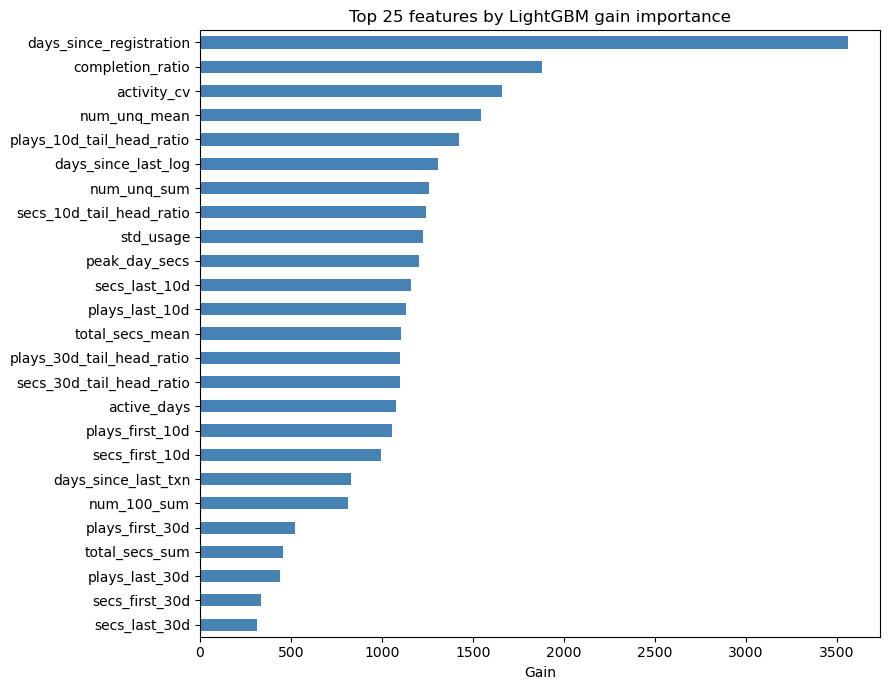

Saved: reports/metrics/feature_importance.png


In [10]:
importance = pd.Series(
    model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
importance.head(25).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 25 features by LightGBM gain importance")
ax.set_xlabel("Gain")
plt.tight_layout()
fig.savefig(REPORTS_DIR / "metrics" / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/metrics/feature_importance.png")

## 7. Generate churn ranking

Score all users (training + validation) to produce the final ranked list. In practice you'd score a fresh batch; here we use the full population to show the output format and generate usable `churn_ranking.csv`.

In [11]:
all_proba = model.predict_proba(X)[:, 1]

p90 = np.percentile(all_proba, 90)
p75 = np.percentile(all_proba, 75)

def assign_tier(p):
    if p >= p90:
        return "high"
    elif p >= p75:
        return "medium"
    return "low"

ranking = pd.DataFrame({
    "msno":        user_ids,
    "is_churn":    y.values,
    "churn_proba": all_proba.round(6),
    "risk_tier":   [assign_tier(p) for p in all_proba],
}).sort_values("churn_proba", ascending=False).reset_index(drop=True)

ranking["rank"] = np.arange(1, len(ranking) + 1)

print(f"Total users ranked: {len(ranking):,}")
print("\nTier distribution:")
print(ranking["risk_tier"].value_counts().to_string())
print("\nTop 10 highest-risk users:")
display(ranking.head(10))

Total users ranked: 970,960

Tier distribution:
risk_tier
low       728220
medium    145577
high       97163

Top 10 highest-risk users:


,msno,is_churn,churn_proba,risk_tier,rank
0,FEbhnx43WgdtB1WiJTW58y6lBAaBPWQ087TCqcQjUSg=,1,0.999946,high,1
1,qm5PBi2Qa/pddgPmmMB1Yl8qmJAgdW8jMQP58YBZP+g=,1,0.999942,high,2
2,aPjC5wEeOv7wIl3frl8gvF5q6fsdKE7tDAC0l0j82WE=,1,0.999931,high,3
3,3V7reBDv6Wr1LRQ78JvsVaK3FMWOOB91+3volQEAAWA=,1,0.999930,high,4
4,OOszdzx9WjPoynUFJwZsO60/gtUHFsCHq9XW2vXkqzE=,1,0.999929,high,5
5,9RsWNySsy1B6opp8g3kJmvIY2AkHk6g3DzgI6uy2h+A=,1,0.999907,high,6
6,t79Xqh0WmoZ/fbNm+yuLhsA4qmJgxEeqw12yqIPyHGk=,1,0.999905,high,7
7,dE7RKpHTsZfgRGFf1j9nfPqpIWEFd0uZtCWNwqGtT9U=,1,0.999904,high,8
8,Beo9dRgY+0iTmjqwTMfhl/+E2n2lDwah1ud4eBTuKp4=,1,0.999893,high,9
9,teObVR9fWI9KtV/5to0+mJc7xXt1vlHZpV9xAfO989w=,1,0.999891,high,10


## 8. Save outputs

In [12]:
ranking_path = ROOT / "data" / "processed" / "churn_ranking.csv"
ranking.to_csv(ranking_path, index=False)
print(f"Saved: {ranking_path.relative_to(ROOT)}")

top_users_dir = REPORTS_DIR / "top_users"
for pct in [1, 5, 10]:
    k = max(1, int(len(ranking) * pct / 100))
    out = ranking.head(k)[["msno", "churn_proba", "risk_tier", "rank"]]
    path = top_users_dir / f"top_{pct}_percent.csv"
    out.to_csv(path, index=False)
    print(f"Saved top {pct:2d}% ({k:,} users) → {path.relative_to(ROOT)}")

metrics_path = REPORTS_DIR / "metrics" / "final_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"\nSaved: {metrics_path.relative_to(ROOT)}")

Saved: data\processed\churn_ranking.csv
Saved top  1% (9,709 users) → reports\top_users\top_1_percent.csv
Saved top  5% (48,548 users) → reports\top_users\top_5_percent.csv
Saved top 10% (97,096 users) → reports\top_users\top_10_percent.csv

Saved: reports\metrics\final_metrics.json


## 9. Summary

| Output | Path |
|---|---|
| Full churn ranking | `data/processed/churn_ranking.csv` |
| Final metrics | `reports/metrics/final_metrics.json` |
| ROC / PR curves | `reports/metrics/roc_pr_curves.png` |
| Recall@K curve | `reports/metrics/recall_at_k.png` |
| Feature importance | `reports/metrics/feature_importance.png` |
| Top 1% users | `reports/top_users/top_1_percent.csv` |
| Top 5% users | `reports/top_users/top_5_percent.csv` |
| Top 10% users | `reports/top_users/top_10_percent.csv` |

---

### Summary

ROC AUC 0.778, up from ~0.620 with logistic regression. Average Precision 0.476 vs a ~0.090 random baseline.

At the 25k budget (13% of validation users), the model captures 51.1% of all churners. The same budget applied randomly would catch ~2.6%. At 50k users (26%), it reaches 64.1% of churners.

The biggest single improvement in the whole project came from adding the March 2017 user log features in notebook 06 — about +0.10 AUC. The pipeline v2 windows and interactions added another ~0.002 on top of that.